# Unemployment in India (Covid-19) 👨‍💼🐘🦠

## 1️⃣ Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 

## 2️⃣ Read the Dataset

In [2]:
path = '/kaggle/input/unemployment-in-india/Unemployment in India.csv'
df = pd.read_csv(path)

In [3]:
df.shape

(768, 7)

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### 📊 Dataset Attributes Summary

This dataset consists of 7 key attributes used to analyze the economic and employment landscape across different states in India, specifically focusing on the impact of the COVID-19 pandemic.

#### Column Definitions

| Attribute Name                     | Description                                                                 |
|-----------------------------------|-----------------------------------------------------------------------------|
| **Region**                         | The specific state or administrative region in India.                       |
| **Date**                           | The month and year the data was recorded (May 2019 – June 2020).            |
| **Frequency**                      | The interval of data collection (Monthly).                                  |
| **Estimated Unemployment Rate (%)**| The percentage of the labor force that is unemployed.                        |
| **Estimated Employed**             | The total estimated headcount of individuals currently employed.            |
| **Estimated Labour Participation Rate (%)** | The percentage of the working-age population that is either working or seeking work. |
| **Area**                            | Geographic classification of the record (Rural or Urban).                   |

## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


### Check Columns 

In [6]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

#### Solve Problem Space

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

#### Drop Unimportant Columns 

In [9]:
df.drop(columns=['Frequency'], inplace=True)

#### Change Column Data 

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_17/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
type(df['Date'].values.dtype)

numpy.dtypes.DateTime64DType

### Description

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,NaN,NaN,NaN,2019-12-12 18:36:58.378378496,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,740,2019-12-12 18:36:58.378378496,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Estimated Unemployment Rate (%),740.0,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094


### Check Missing values and Handel 

In [14]:
df.isna().sum()

Region                                     28
Date                                       28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [15]:
(df.isna().sum() / df.shape[0]) * 100

Region                                     3.645833
Date                                       3.645833
Estimated Unemployment Rate (%)            3.645833
Estimated Employed                         3.645833
Estimated Labour Participation Rate (%)    3.645833
Area                                       3.645833
dtype: float64

#### Percentage of Missing Values per Column

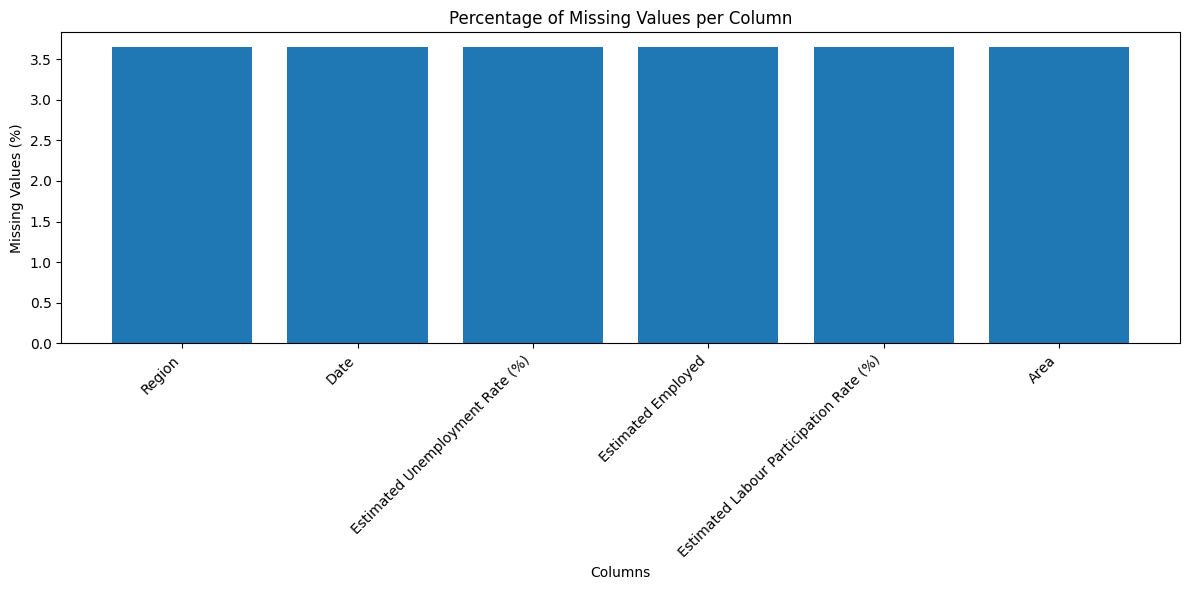

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(x= df.columns, height= (df.isna().sum() / df.shape[0]) * 100 )
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Values (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Handel Categorical Columns 

In [17]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['Region', 'Area'], dtype='object')

In [18]:
for i in cat_cols:
    df[i].fillna(value= df[i].mode()[0] , inplace=True)

/tmp/ipykernel_17/2218172583.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value= df[i].mode()[0] , inplace=True)


#### Handel Numeric Columns 

In [19]:
num_cols = df.select_dtypes(['float64' , 'datetime64[ns]']).columns
num_cols

Index(['Date', 'Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)'],
      dtype='object')

In [20]:
for i in num_cols:
    df[i].fillna(value= df[i].median() , inplace=True)

/tmp/ipykernel_17/1543731380.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value= df[i].median() , inplace=True)


In [21]:
df.isna().sum()

Region                                     0
Date                                       0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

### Categorical Columns 

In [22]:
cat_cols

Index(['Region', 'Area'], dtype='object')

In [23]:
for i in cat_cols:
    print(df[i].value_counts())
    print('Number of Keys = ', len(df[i].value_counts().keys()))
    print('-' * 20)

Region
Andhra Pradesh      56
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64
Number of Keys =  28
--------------------
Area
Urban    409
Rural    359
Name: count, dtype: int64
Number of Keys =  2
--------------------


#### Distribution of Regions 

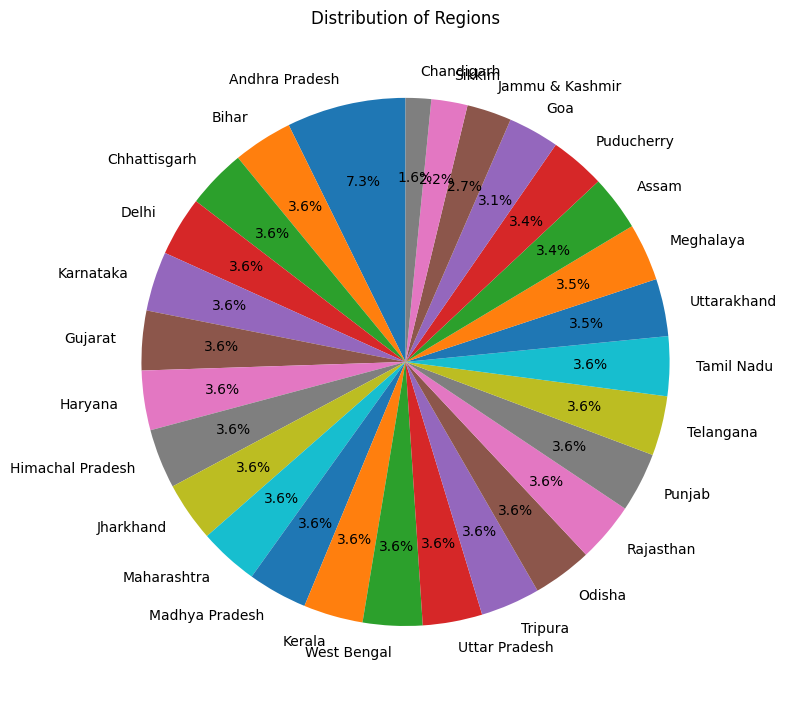

In [24]:
plt.figure(figsize=(8,8))
plt.pie(
    df['Region'].value_counts().values,
    labels=df['Region'].value_counts().index,
    autopct='%1.1f%%',     
    startangle=90,         
    pctdistance=0.7,       
    labeldistance=1.1       
)
plt.title('Distribution of Regions')
plt.tight_layout()
plt.show()


#### Distribution top 10 Regions

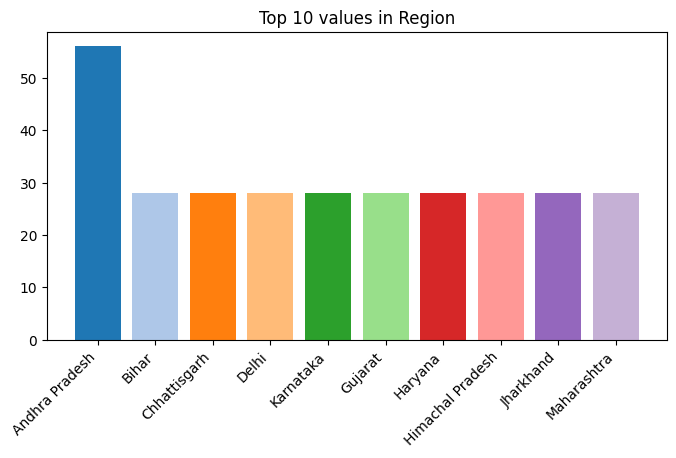

In [25]:
plt.figure(figsize=(8,4))
plt.bar(x=df['Region'].value_counts()[:10].keys(),
            height=df['Region'].value_counts()[:10].values,
            color=plt.cm.tab20.colors)
plt.title(f'Top 10 values in Region')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Distribution of Area

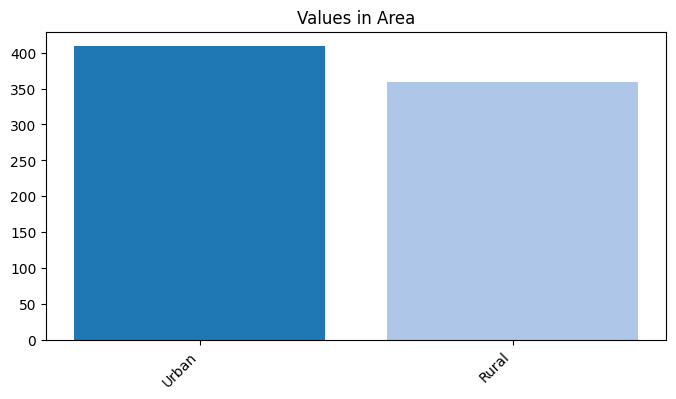

In [26]:
plt.figure(figsize=(8,4))
plt.bar(x=df['Area'].value_counts().keys(),
            height=df['Area'].value_counts().values,
            color=plt.cm.tab20.colors)
plt.title(f'Values in Area')
plt.xticks(rotation=45, ha='right')
plt.show()

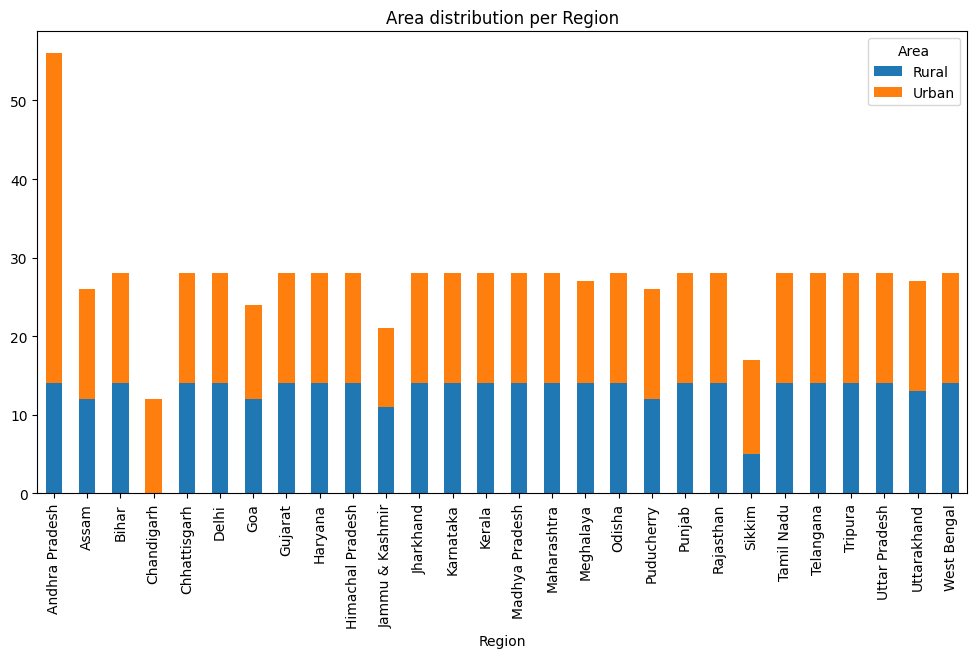

In [27]:
pd.crosstab(df['Region'], df['Area']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Area distribution per Region')
plt.show()

### Numeric Columns 

In [28]:
num_cols[1:]

Index(['Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)'],
      dtype='object')

#### Histogram for numeric columns 

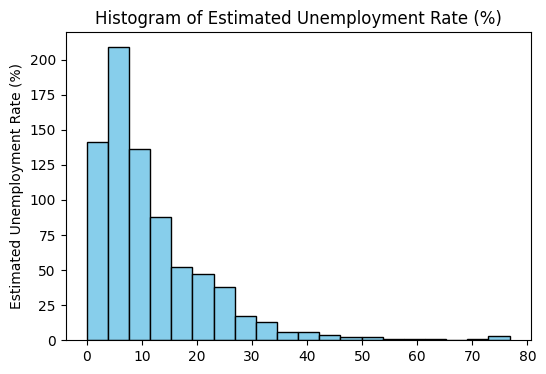

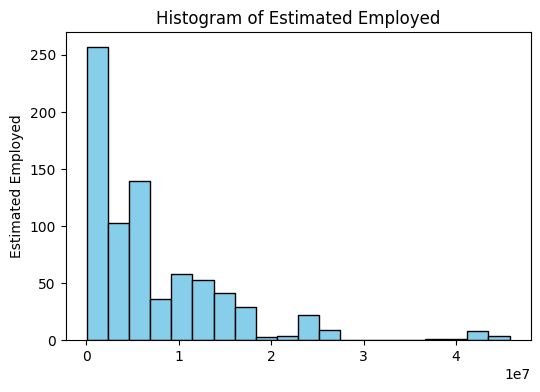

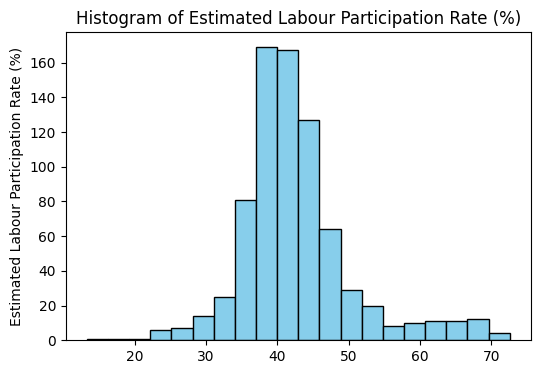

In [29]:
for i in num_cols[1:]:
    plt.figure(figsize=(6,4))
    plt.hist(df[i], bins=20, edgecolor='black', color='skyblue')
    plt.title(f'Histogram of {i}')
    plt.ylabel(i)
    plt.show()

#### Boxplot for numeric columns 

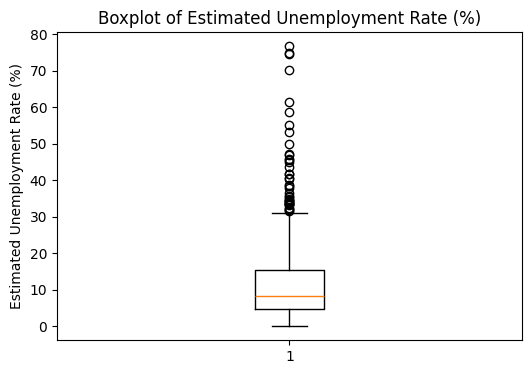

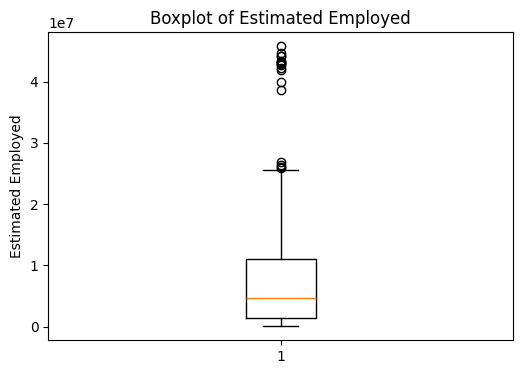

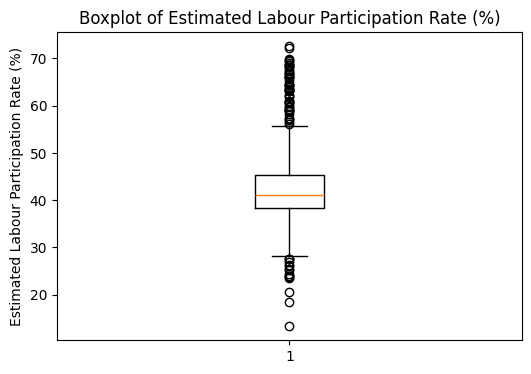

In [30]:
for i in num_cols[1:]:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.ylabel(i)
    plt.show()

#### Unemployment Rate Distribution: Urban vs Rural

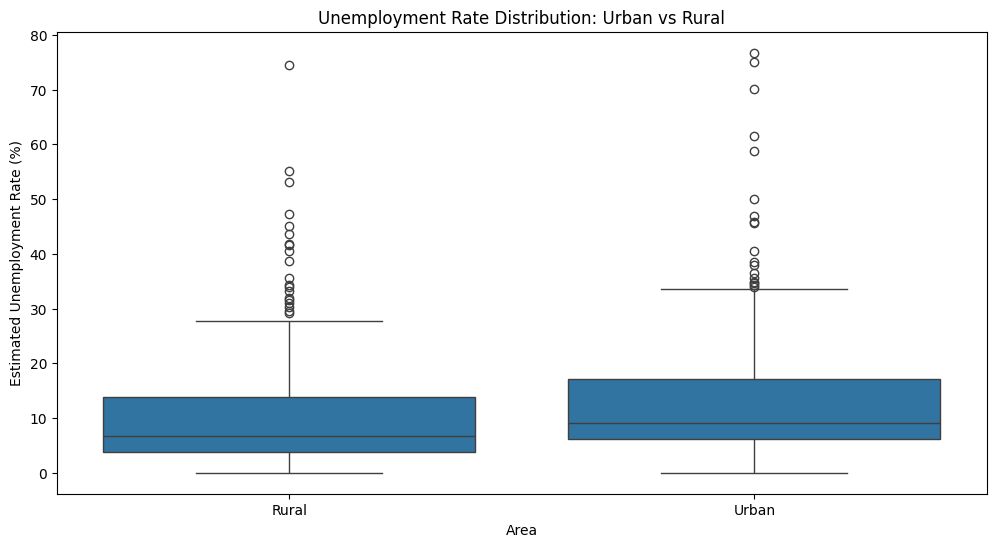

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title('Unemployment Rate Distribution: Urban vs Rural')
plt.show()

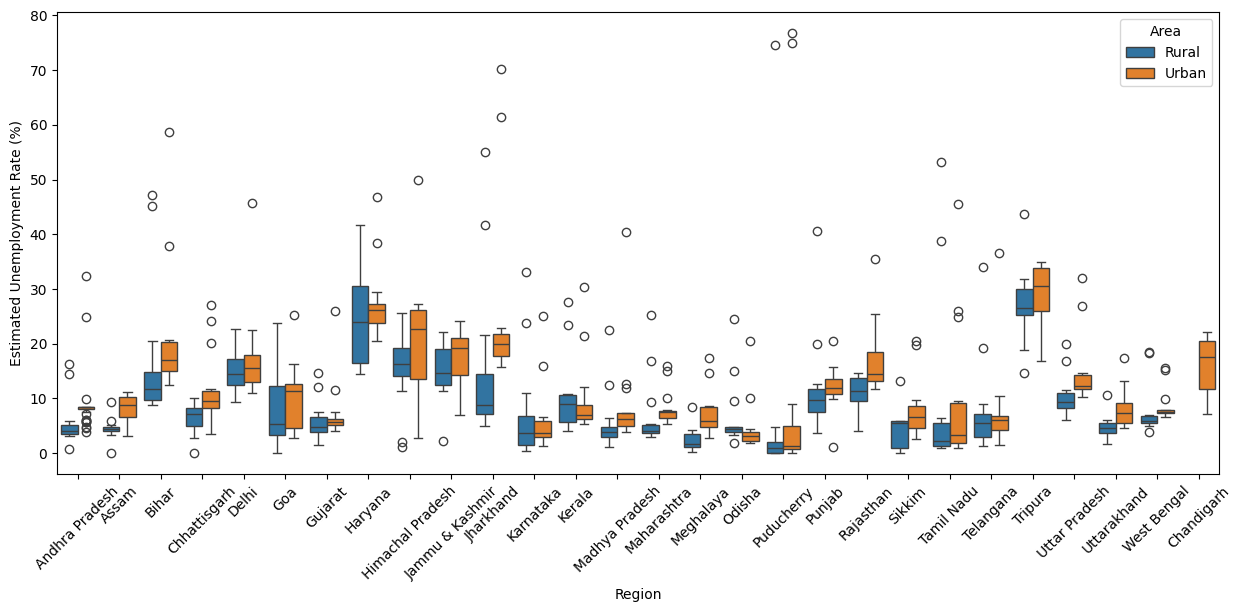

In [32]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Region', y='Estimated Unemployment Rate (%)',hue='Area',  data=df)
plt.xticks(rotation=45)
plt.show()

#### Estimated Unemployment Rate Over Time

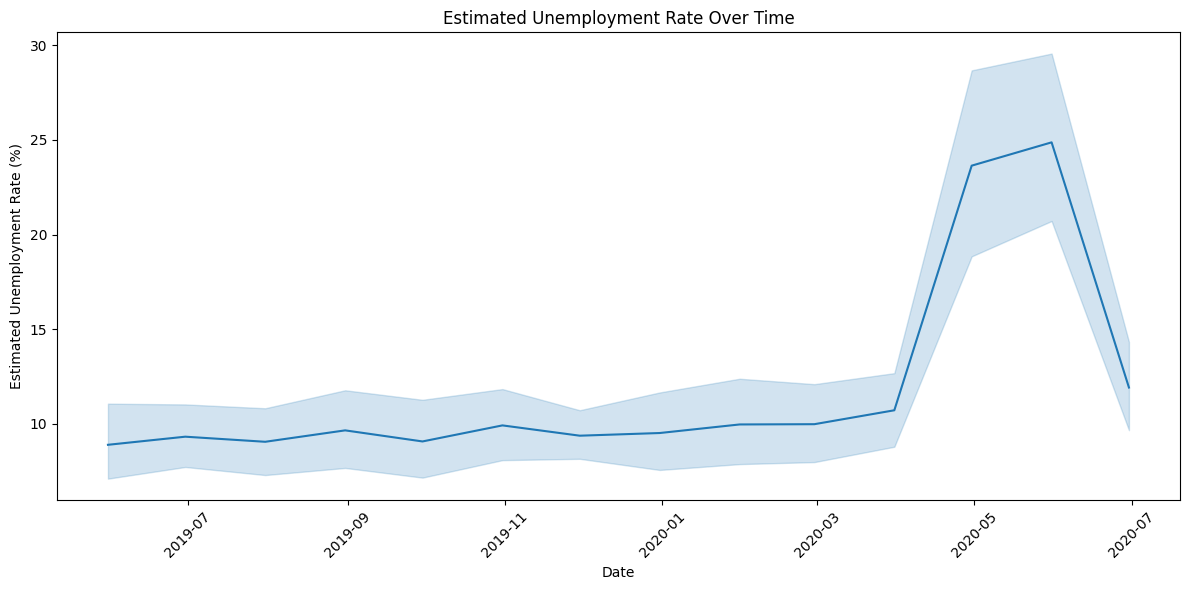

In [33]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df , y='Estimated Unemployment Rate (%)', x='Date')
plt.title('Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_17/1335296778.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


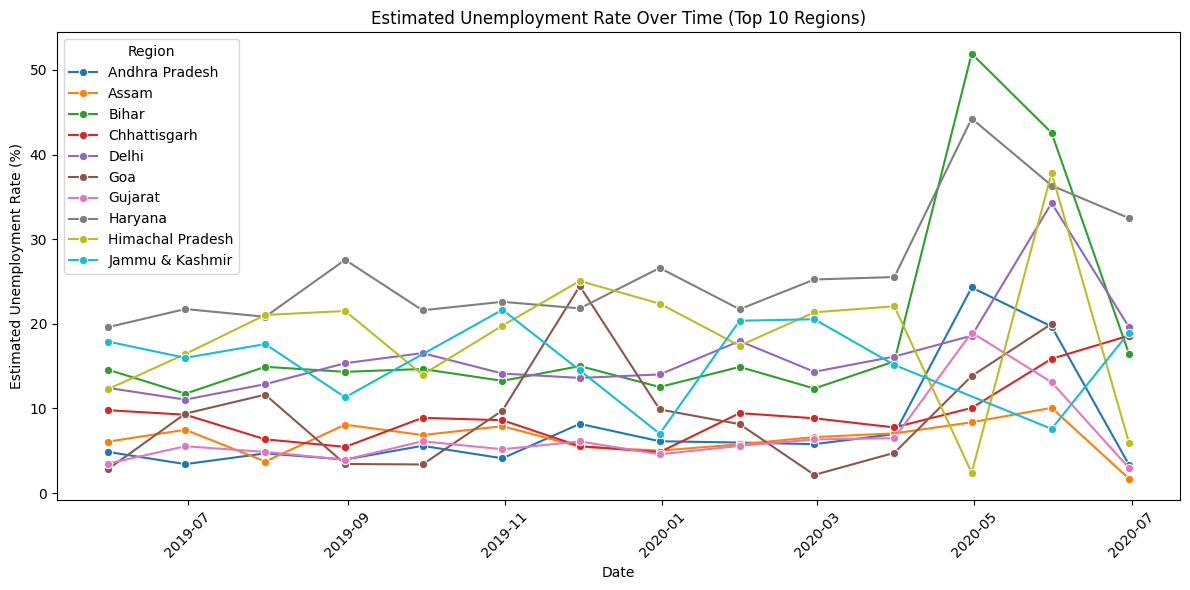

In [34]:
top_regions = df['Region'].unique()[:10]
df_top = df[df['Region'].isin(top_regions)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top, x='Date', y='Estimated Unemployment Rate (%)', 
    hue='Region', marker='o',ci=None
)
plt.xticks(rotation=45)
plt.title('Estimated Unemployment Rate Over Time (Top 10 Regions)')
plt.tight_layout()
plt.show()

#### Correlation Heatmap

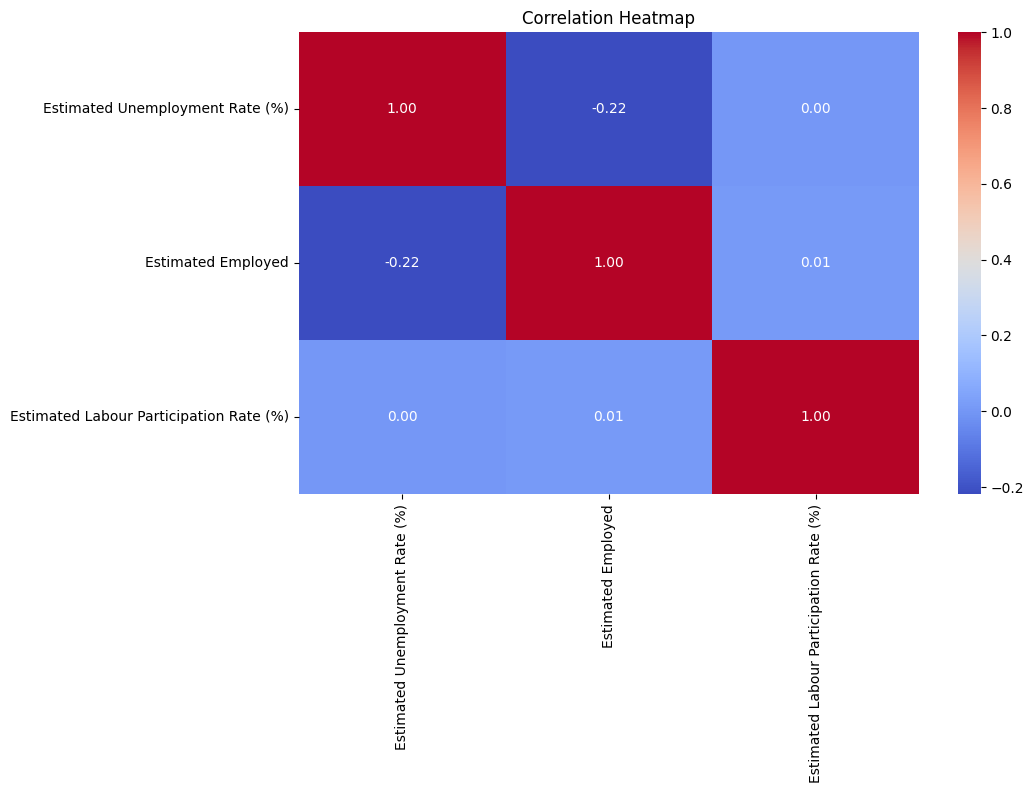

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Estimated Unemployment Rate (%)', 
                'Estimated Employed', 
                'Estimated Labour Participation Rate (%)']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

#### Average Unemployment Rate per State

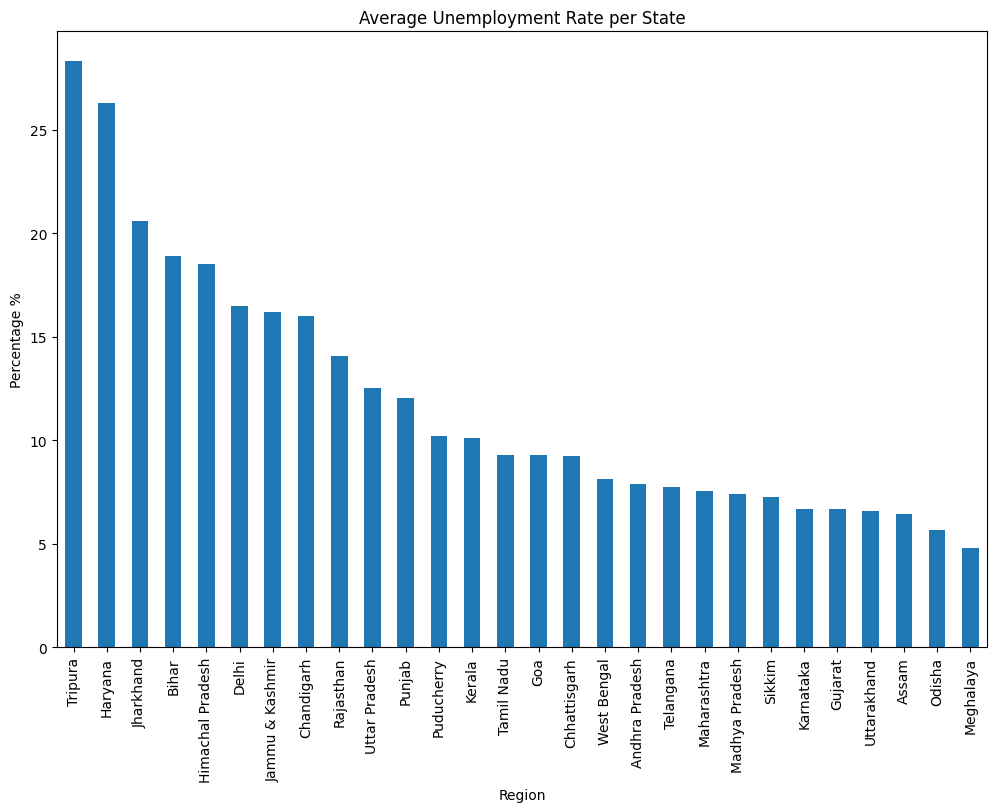

In [36]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,8))
state_avg.plot(kind='bar')
plt.title('Average Unemployment Rate per State')
plt.ylabel('Percentage %')
plt.show()

In [37]:
before_lockdown = df[df['Date'] < '2020-04-01']
during_lockdown = df[df['Date'] >= '2020-04-01']

print(f"Average Unemployment Before: {before_lockdown['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Average Unemployment During: {during_lockdown['Estimated Unemployment Rate (%)'].mean():.2f}%")

Average Unemployment Before: 9.56%
Average Unemployment During: 20.19%


## 4️⃣ Important Insights 

### 1️⃣ The Lockdown Shock

In [38]:
df_before = df[df['Date'] < '2020-04-01']
df_after = df[df['Date'] >= '2020-04-01' ]

print(f"Average Unemployment Before: {df_before['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Average Unemployment During: {df_after['Estimated Unemployment Rate (%)'].mean():.2f}%")

Average Unemployment Before: 9.56%
Average Unemployment During: 20.19%


Text(0.5, 1.0, 'Estimated Unemployment Rate Over Time')

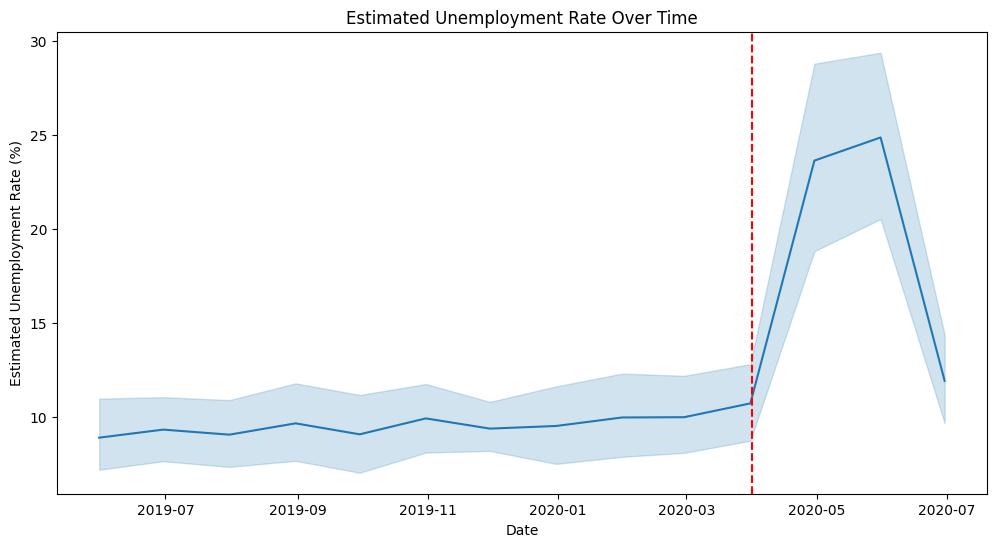

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df , y='Estimated Unemployment Rate (%)', x='Date')
plt.axvline(x=pd.to_datetime('2020-04-01'), color='red', linestyle='--', linewidth=1.5, label='Threshold')
plt.title('Estimated Unemployment Rate Over Time')

**Conclusion:**  
The visualization clearly demonstrates a "vertical jump" in unemployment rates starting from April 2020. The average national unemployment rate surged from approximately 9.5% to over 20% within a single month. This sharp spike perfectly aligns with the implementation of the nationwide lockdown in India, marking it as the most significant economic shock in the dataset.

### 2️⃣ Regional Impact Map

In [40]:
df['Region'].value_counts()[:5]

Region
Andhra Pradesh    56
Bihar             28
Chhattisgarh      28
Delhi             28
Karnataka         28
Name: count, dtype: int64

In [41]:
impact = {}

for region in df['Region'].value_counts()[:5].keys():
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    print(f"State : {region}")
    print(f"Average Unemployment Before: {df_before['Estimated Unemployment Rate (%)'].mean():.2f}%")
    print(f"Average Unemployment During: {df_after['Estimated Unemployment Rate (%)'].mean():.2f}%")
    difference = abs(df_before['Estimated Unemployment Rate (%)'].mean() - df_after['Estimated Unemployment Rate (%)'].mean())
    impact[region] = difference
    
    print('-' * 20)

State : Andhra Pradesh
Average Unemployment Before: 6.97%
Average Unemployment During: 15.78%
--------------------
State : Bihar
Average Unemployment Before: 13.99%
Average Unemployment During: 36.99%
--------------------
State : Chhattisgarh
Average Unemployment Before: 7.71%
Average Unemployment During: 14.85%
--------------------
State : Delhi
Average Unemployment Before: 14.40%
Average Unemployment During: 24.17%
--------------------
State : Karnataka
Average Unemployment Before: 3.27%
Average Unemployment During: 19.16%
--------------------


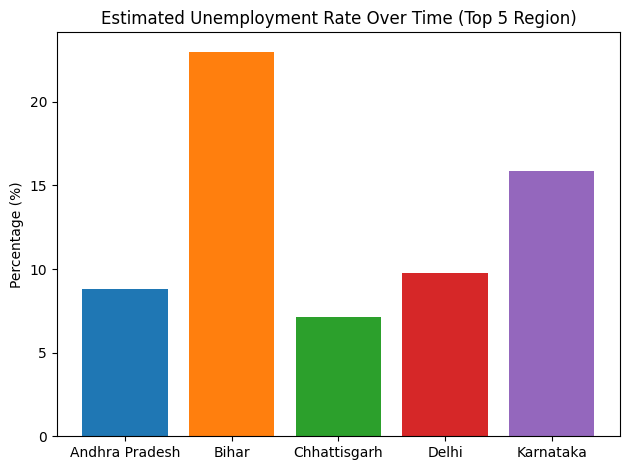

In [42]:
plt.title('Estimated Unemployment Rate Over Time (Top 5 Region)')
for k,v in impact.items():
    plt.bar(x=k , height=v)
    plt.show
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

**Conclusion:**   
While all states were affected, the impact was not uniform. States like West Bengal and Uttar Pradesh showed significant absolute increases in their unemployment averages. This disparity suggests that states with higher industrial or service-sector dependency faced a much harder hit compared to those with a more resilient agricultural base

### 3️⃣ Urban vs Rural Divide

In [43]:
impact_list = []

for region in df['Region'].value_counts()[:5].keys():
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    for area in df['Area'].unique():
        df_b_area = df_before[df_before['Area'] == area]
        df_a_area = df_after[df_after['Area'] == area]
        
        avg_before = df_b_area['Estimated Unemployment Rate (%)'].mean()
        avg_after = df_a_area['Estimated Unemployment Rate (%)'].mean()
        
        difference = abs(avg_after - avg_before)
        
        impact_list.append({
            'Region': region,
            'Area': area,
            'Difference': difference
        })

impact_df = pd.DataFrame(impact_list)

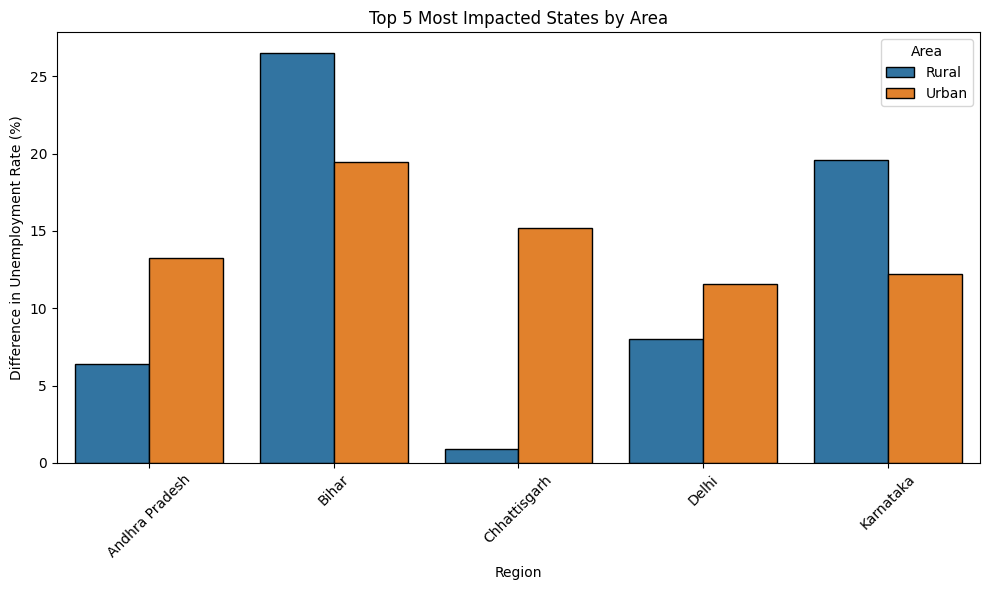

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=impact_df, 
    x='Region', 
    y='Difference', 
    hue='Area', 
    edgecolor='black'
)
plt.title('Top 5 Most Impacted States by Area')
plt.ylabel('Difference in Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Area')
plt.tight_layout()
plt.show()

**Conclusion:**  
The data confirms that Urban areas consistently faced higher unemployment rates and sharper increases compared to Rural areas. This is likely due to the total shutdown of construction, manufacturing, and service industries in cities, whereas rural economies were partially buffered by the continuation of essential agricultural activities.

### 4️⃣ Labor Force Mystery

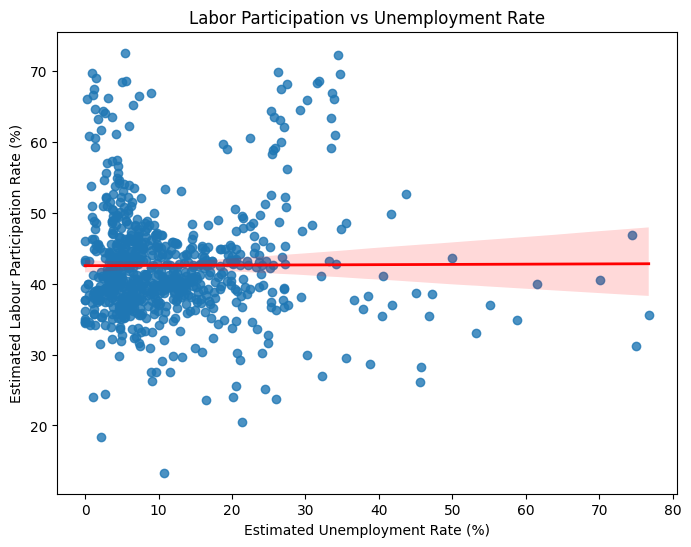

In [45]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    y='Estimated Labour Participation Rate (%)',
    line_kws={'color':'red', 'linewidth':2}
)
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Estimated Labour Participation Rate (%)')
plt.title('Labor Participation vs Unemployment Rate')
plt.show()


**Conclusion:**   
 The regression plot reveals a negative correlation between the Unemployment Rate and the Labor Participation Rate. This indicates a "Discouraged Worker Effect," where as jobs became scarce, a segment of the workforce stopped looking for work altogether and exited the labor market, further complicating the economic recovery.

### 5️⃣ Massive Job Loss

In [46]:
for region in df['Region'].value_counts()[:5].keys(): 
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    mean_before = df_before['Estimated Employed'].mean()
    mean_after = df_after['Estimated Employed'].mean()
    
    loss = mean_before - mean_after
    
    loss_percentage = (loss / mean_before) * 100
    
    print(f"Region: {region}")
    print(f"Avg Employed before lockdown: {mean_before / 1000000 :.2f} Million")
    print(f"Avg Employed during lockdown: {mean_after / 1000000 :.2f} Million")
    print(f"Actual job loss: {loss / 1000000 :.2f} Million people")
    print(f"Job loss percentage: {loss_percentage:.2f}%")
    
    print('-' * 20)

Region: Andhra Pradesh
Avg Employed before lockdown: 6.33 Million
Avg Employed during lockdown: 7.47 Million
Actual job loss: -1.14 Million people
Job loss percentage: -18.07%
--------------------
Region: Bihar
Avg Employed before lockdown: 13.19 Million
Avg Employed during lockdown: 9.34 Million
Actual job loss: 3.85 Million people
Job loss percentage: 29.18%
--------------------
Region: Chhattisgarh
Avg Employed before lockdown: 4.49 Million
Avg Employed during lockdown: 3.62 Million
Actual job loss: 0.87 Million people
Job loss percentage: 19.40%
--------------------
Region: Delhi
Avg Employed before lockdown: 2.89 Million
Avg Employed during lockdown: 1.67 Million
Actual job loss: 1.22 Million people
Job loss percentage: 42.24%
--------------------
Region: Karnataka
Avg Employed before lockdown: 10.84 Million
Avg Employed during lockdown: 10.04 Million
Actual job loss: 0.80 Million people
Job loss percentage: 7.38%
--------------------


**Conclusion:**  
 Translating percentages into human impact, we observe a staggering loss of livelihoods. In major states like Uttar Pradesh and West Bengal, the average number of employed people dropped by millions during the lockdown months. For instance, some states saw a decline of over 15-20% in their total workforce, highlighting the massive scale of the social crisis beyond just statistical percentages.

## Thank you 🎀🫶🏻